# Hand Gesture Recognition

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import libemg

import gc

In [9]:
# global variables
TEST_SUBJECTS = ("nad",)
DATA_DIR = "../../recordings/19_12_24"
SENSOR_PLACEMENT = 0
#GESTURES =  ("down", "fist", "fup", "index", "ok", "open", "peace", "thumb", "up")
GESTURES =  ("fist", "index", "middle", "ok", "peace", "thumb")
NUM_CLASSES = len(GESTURES)
lf = 20
hf = 500
fs = 1150
trim = 4 * 8 * 5
bandpass_order = 4
outlier_rejection_stds = 6

PLOT_ALL_TIMELINE = False
NUM_SENSORS = 4
RANDOM_STATE = 42
SUBSAMPLE_DATA = True

In [10]:
import re

# structure: recordings/date/data/*.csv
recordings = []
baseline_file = None

pattern = re.compile(rf"({'|'.join(TEST_SUBJECTS)})_({'|'.join(GESTURES)})\d*_{SENSOR_PLACEMENT}.csv")

for date_dir, _, filenames in os.walk(DATA_DIR):
    if date_dir.endswith('data'):
        for filename in filenames:
            if pattern.match(filename):
                gesture = next((gesture for gesture in GESTURES if gesture in filename), None)
                
                # TODO: Add check if the file has the desired number of sensors recorded
                
                recordings.append({
                    "gesture": gesture,
                    "raw_data_filepath": os.path.join(date_dir, filename),
                    "imu_data_filepath": os.path.join(date_dir, f'imu_{filename}') if os.path.exists(os.path.join(date_dir, f'imu_{filename}')) else None,
                    'fft_data_filepath': os.path.join(date_dir, f'fft_{filename}') if os.path.exists(os.path.join(date_dir, f'fft_{filename}')) else None,
                })

print(recordings)


[{'gesture': 'fist', 'raw_data_filepath': '../../recordings/19_12_24\\data\\nad_fist_0.csv', 'imu_data_filepath': '../../recordings/19_12_24\\data\\imu_nad_fist_0.csv', 'fft_data_filepath': '../../recordings/19_12_24\\data\\fft_nad_fist_0.csv'}, {'gesture': 'index', 'raw_data_filepath': '../../recordings/19_12_24\\data\\nad_index_0.csv', 'imu_data_filepath': '../../recordings/19_12_24\\data\\imu_nad_index_0.csv', 'fft_data_filepath': '../../recordings/19_12_24\\data\\fft_nad_index_0.csv'}, {'gesture': 'middle', 'raw_data_filepath': '../../recordings/19_12_24\\data\\nad_middle_0.csv', 'imu_data_filepath': '../../recordings/19_12_24\\data\\imu_nad_middle_0.csv', 'fft_data_filepath': '../../recordings/19_12_24\\data\\fft_nad_middle_0.csv'}, {'gesture': 'ok', 'raw_data_filepath': '../../recordings/19_12_24\\data\\nad_ok_0.csv', 'imu_data_filepath': '../../recordings/19_12_24\\data\\imu_nad_ok_0.csv', 'fft_data_filepath': '../../recordings/19_12_24\\data\\fft_nad_ok_0.csv'}, {'gesture': 'pe

In [11]:
dfs = [[] for _ in range(NUM_CLASSES)]

for recording in recordings:
    dfs[GESTURES.index(recording["gesture"])].append(pd.read_csv(recording["raw_data_filepath"], header=None))

Optional subsampling:

In [12]:
def get_min_df_array_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

def get_min_df_len(dfs):
    min_len = min([len(df) for df in dfs])
    return min_len

def get_random_df_chunk(df, chunk_len):
    if len(df) == chunk_len:
        return df
    start = np.random.randint(0, len(df) - chunk_len)
    return df[start:start+chunk_len]

In [13]:
print([len(df_) for df in dfs for df_ in df])

[4554, 4874, 4805, 4797, 4807, 4805]


In [14]:
concat_dfs = []

for i in range(NUM_CLASSES):
    if SUBSAMPLE_DATA:
        min_len = get_min_df_array_len(dfs)
        concat_dfs.append(pd.concat([get_random_df_chunk(df, min_len) for df in dfs[i]], ignore_index=True))
    else:
        concat_dfs.append(pd.concat(dfs[i], ignore_index=True))

In [17]:
print([len(df) for df in concat_dfs])

[4554, 4554, 4554, 4554, 4554, 4554]


Combine dataframes

In [18]:
sensor_data = pd.concat(concat_dfs, ignore_index=True)
labels = sum([[i] * len(concat_dfs[i]) for i in range(NUM_CLASSES)], [])
print(sensor_data.head())

      0      1      2      3      4      5      6      7      8      9   ...  \
0  18383  18386  18399  18399  18384  18381  18377  18398  18240  18252  ...   
1  18305  18316  18320  18323  18310  18292  18282  18290  18165  18157  ...   
2  18305  18316  18320  18323  18310  18292  18282  18290  18165  18157  ...   
3  18280  18274  18268  18262  18259  18306  18305  18314  18165  18157  ...   
4  18280  18274  18268  18262  18259  18306  18305  18314  18223  18232  ...   

      22     23     24     25     26     27     28     29     30     31  
0  18232  18231  18374  18364  18329  18334  18318  18359  18360  18350  
1  18224  18231  18311  18301  18308  18245  18270  18282  18287  18278  
2  18224  18231  18287  18296  18310  18295  18292  18300  18288  18277  
3  18224  18231  18287  18296  18310  18295  18292  18300  18288  18277  
4  18224  18231  18287  18296  18310  18295  18292  18300  18288  18277  

[5 rows x 32 columns]


## Preprocessing

In [20]:
import libemg
import numpy as np
from numpy import mean, std
from scipy import signal
from scipy.signal import butter


class EMG_preprocessor():
    def __init__(self, lf, hf, fs, trim, filter_order, outlier_rejection_stds, baseline_signal=None, filter_type='band', library='scipy', num_sensors=4):
        self.lf = lf
        self.hf = hf
        self.fs = fs
        self.trim = trim
        self.filter_order = filter_order
        self.outlier_rejection_stds = outlier_rejection_stds
        self.filter_type = filter_type
        self.library = library
        self.num_sensors = num_sensors
        self.baseline_mean = [[0.0] for _ in range(num_sensors)]
        self.baseline_noise = [[0.0] for _ in range(num_sensors)]
        if baseline_signal is not None:
            self.baseline_signal = [[] for _ in range(num_sensors)]
            baseline_signal = np.array_split(baseline_signal, num_sensors, axis=1)
            for i in range(num_sensors):
                self.baseline_signal[i] = np.asarray(baseline_signal[i]).flatten()
                
            print('Baseline signal provided')
            self._calculate_baseline_noise(filter=True) # calculates baseline noise for each sensor
            self._calculate_baseline_mean() # calculates baseline mean for each sensor
            for i in range(num_sensors):
                self.baseline_signal[i] = self.baseline_signal[i] - self.baseline_mean[i]
        else:
            self.baseline_signal = None

    def calibrate(self, sensor_data):
        self.library = self._maximize_SNR(sensor_data)

    def preprocess(self, sensor_data, sensor_num):
        if self.library == 'scipy':
            return self._preprocess_data_scipy(sensor_data, sensor_num)
        elif self.library == 'libemg':
            return self._preprocess_data_libemg(sensor_data, sensor_num)
        else:
            return sensor_data
        
    def _preprocess_data_libemg(self, data, sensor_num):
        # instantiate the filter object with the sampling frequency
        fi = libemg.filtering.Filter(self.fs)
        # install filters to the filter object
        fi.install_common_filters()
        # run the entire first subject dataset through the common filters
        raw_data = fi.filter(data)
        return raw_data
    
    # def _preprocess_data_emg_dsp_lib(self, data, sensor_num):
    #     ref_available = True if self.baseline_signal is not None else False
    #     self.emg_filter = EMG_filter(sample_frequency = self.fs, range_ = 0.5, min_EMG_frequency = self.lf, max_EMG_frequency = self.hf, reference_available = ref_available)
    #     sig = self.emg_filter.filter(data, self.baseline_signal[sensor_num].tolist())
    #     return sig

    def _remove_mean(self, data):
        return data - np.mean(data, axis=0)

    def _preprocess_data_scipy(self, data, sensor_num):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        data = self._remove_mean(data)
        data = self._subtract_baseline(data, sensor_num)
        return data
    
    def _preprocess_baseline_scipy(self, data):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        return data
    
    def _apply_filter(self, data):
        if self.filter_type == 'band':
            return self._apply_bandpass_filter(data)
        elif self.filter_type == 'highlow':
            return self._apply_highpasslowpass_filter(data)
        else:
            return data

    def _apply_bandpass_filter(self, data):
        sos = butter(self.filter_order, (self.lf, self.hf), btype="bandpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        return proc_data
    
    def _apply_highpasslowpass_filter(self, data):
        sos = butter(self.filter_order, self.lf, btype="highpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        sos = butter(self.filter_order, self.hf, btype="lowpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, proc_data)
        return proc_data

    def _remove_outliers(self, data):
        raw_data = data.flatten()
        data_mean, data_std = mean(raw_data), std(raw_data)
        cut_off = data_std * self.outlier_rejection_stds
        lower, upper = data_mean - cut_off, data_mean + cut_off

        outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in raw_data]
        return outliers_removed

    def _remove_artefact(self, data):
        data[:self.trim] = 0
        return data
    
    def _calculate_baseline_mean(self):
        for i in range(self.num_sensors):
            self.baseline_mean[i] = np.mean(self.baseline_signal[i], axis=0)
    
    def _calculate_baseline_noise(self, filter=False):
        for i in range(self.num_sensors):
            baseline_signal = self.baseline_signal[i]
            if filter:
                baseline_signal = self._preprocess_baseline_scipy(baseline_signal)
            self.baseline_noise[i] = np.sqrt(np.sum(np.asanyarray(baseline_signal)**2)) / len(baseline_signal)
            print('Baseline noise: ', self.baseline_noise[i])
    
    def signaltonoise(self, signal, sensor_num):
        power_signal = np.sqrt(np.sum(np.asanyarray(signal)**2)) / len(signal)
        snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])
        return snr

    def _subtract_baseline(self, data, sensor_num):
        return data - self.baseline_signal[sensor_num]

# Data visualization

## Sensor signals

In [21]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, NUM_SENSORS, axis=0)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    # Plot each sensor's signal
    signals = np.array_split(dataframe.values, NUM_SENSORS, axis=1)
    fig, axs = plt.subplots(NUM_SENSORS // 2 + NUM_SENSORS % 2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

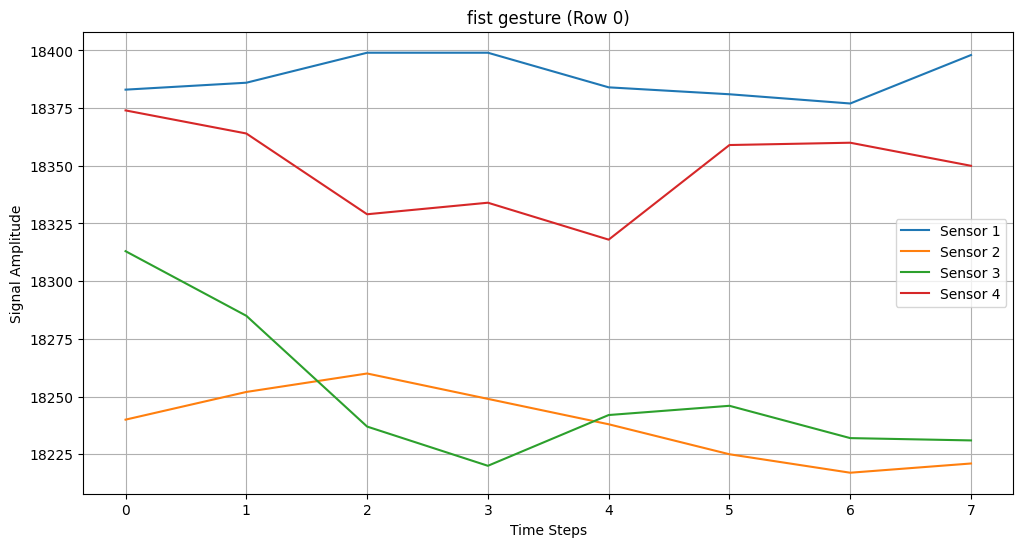

In [22]:
plot_time_signals(concat_dfs[0], row_index=0, title=f'{GESTURES[0]} gesture')

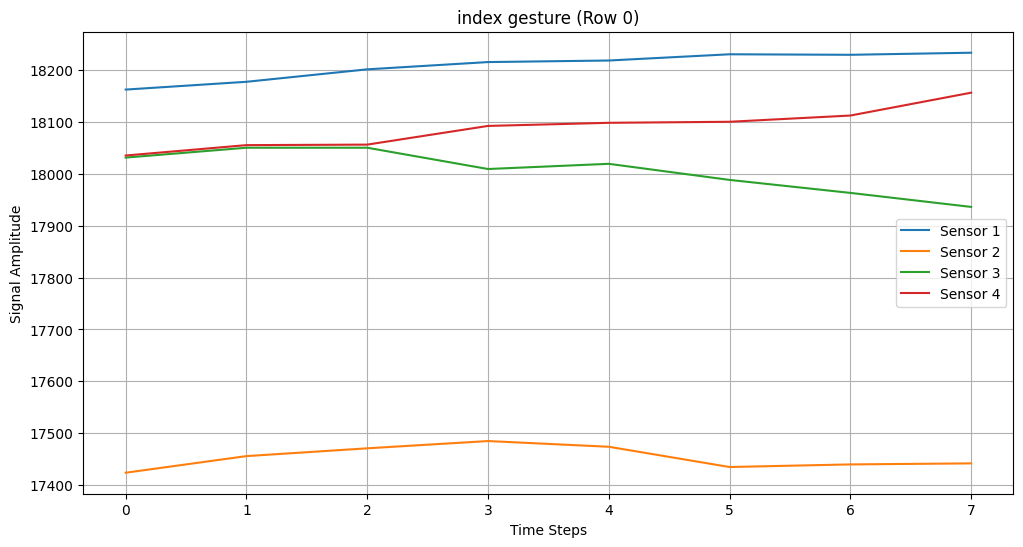

In [23]:
plot_time_signals(concat_dfs[1], row_index=0, title=f'{GESTURES[1]} gesture')

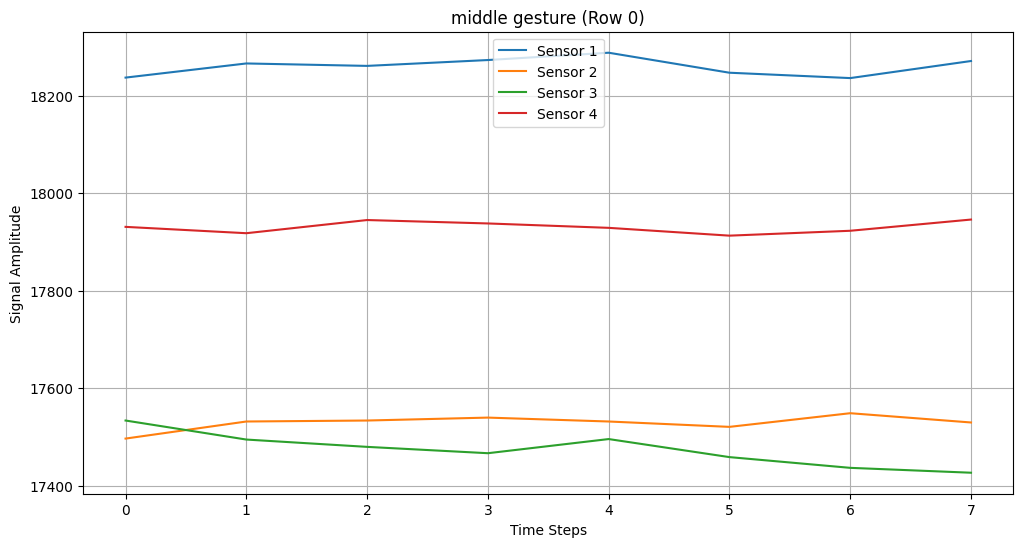

In [24]:
plot_time_signals(concat_dfs[2], row_index=0, title=f'{GESTURES[2]} gesture')

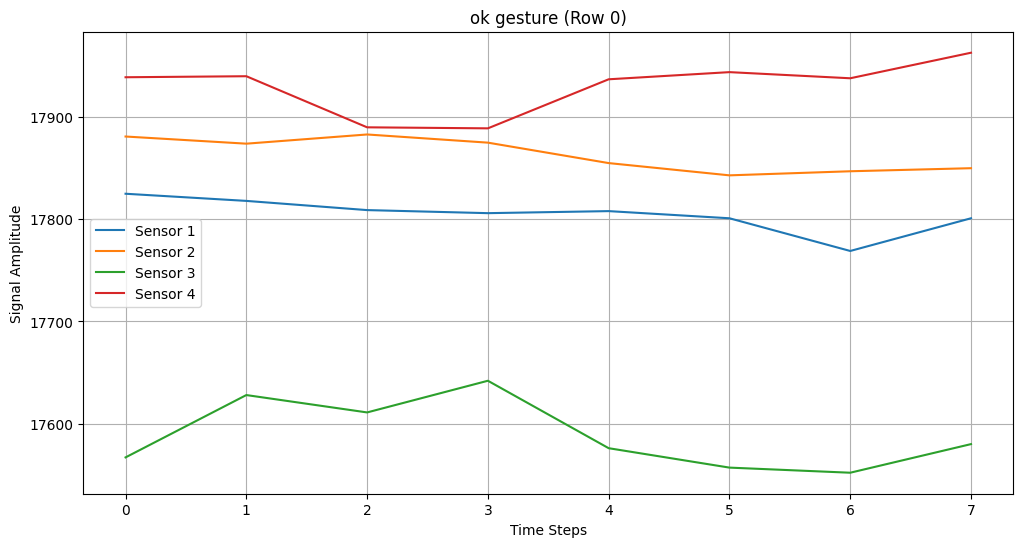

In [25]:
plot_time_signals(concat_dfs[3], row_index=0, title=f'{GESTURES[3]} gesture')

In [26]:
if PLOT_ALL_TIMELINE:
    plot_all_time_signals(concat_dfs[0], title=f'{GESTURES[0]} gesture: whole timeline')
    plot_all_time_signals(concat_dfs[1], title=f'{GESTURES[1]} gesture: whole timeline')
    plot_all_time_signals(concat_dfs[2], title=f'{GESTURES[2]} gesture: whole timeline')
    plot_all_time_signals(concat_dfs[3], title=f'{GESTURES[3]} gesture: whole timeline')
    plot_all_time_signals(concat_dfs[4], title=f'{GESTURES[4]} gesture: whole timeline')

## Preprocessing pipeline tuning

Baseline signal provided
Baseline noise:  0.0
Baseline noise:  0.0
Baseline noise:  0.0
Baseline noise:  0.0


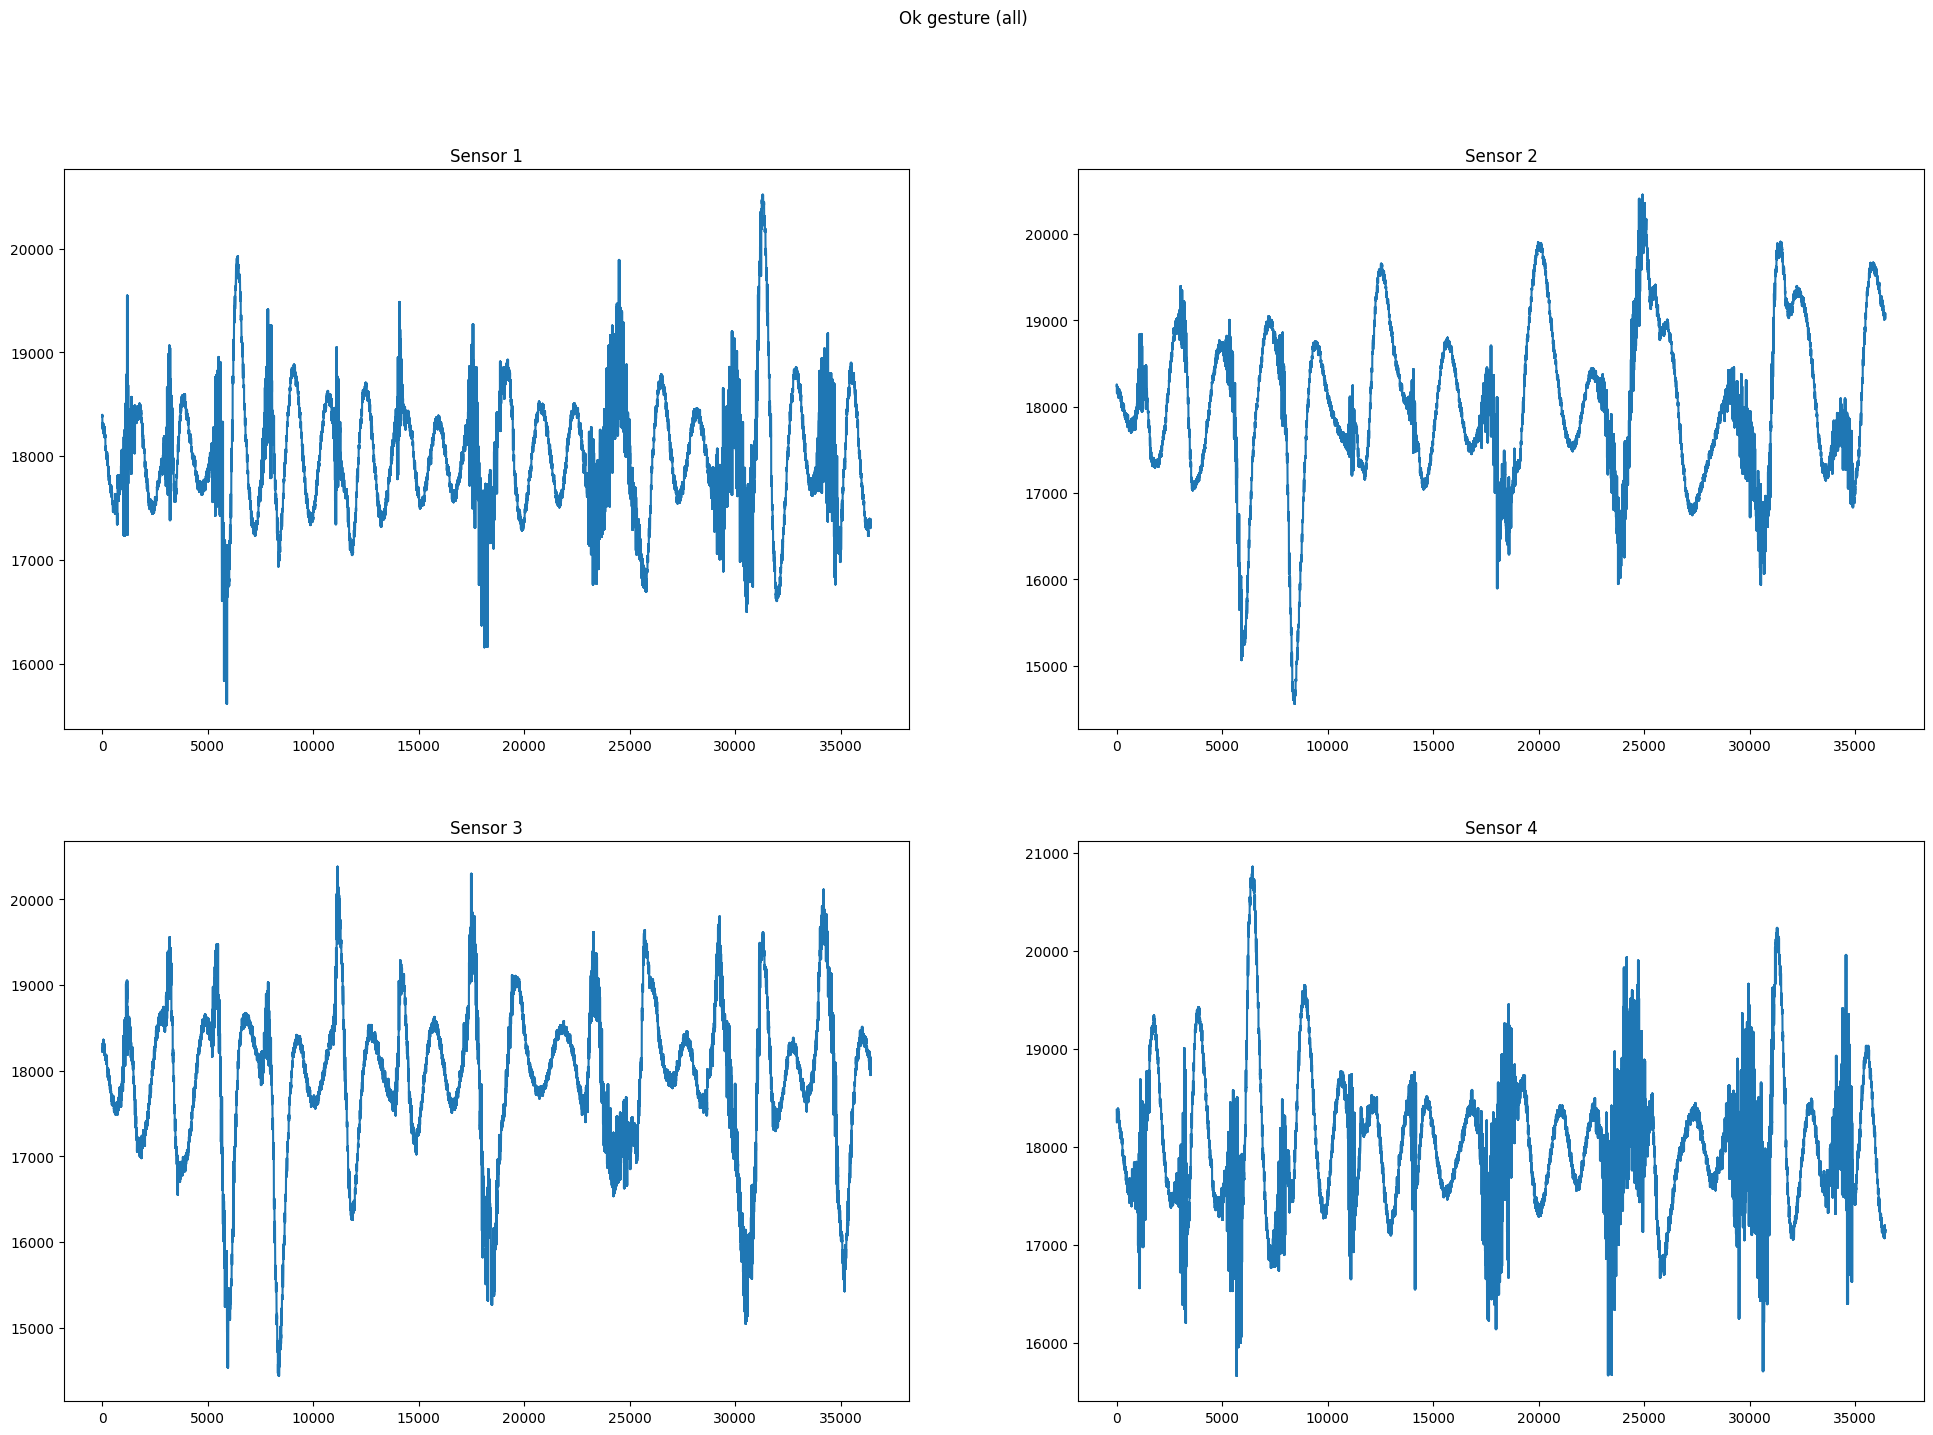

C:\Users\Gilbert\AppData\Local\Temp\ipykernel_20648\3664989093.py:125: RuntimeWarning: divide by zero encountered in scalar divide
  snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])


Raw SNR:  inf
Processed SNR:  inf
Raw SNR:  inf
Processed SNR:  inf
Raw SNR:  inf
Processed SNR:  inf
Raw SNR:  inf
Processed SNR:  inf


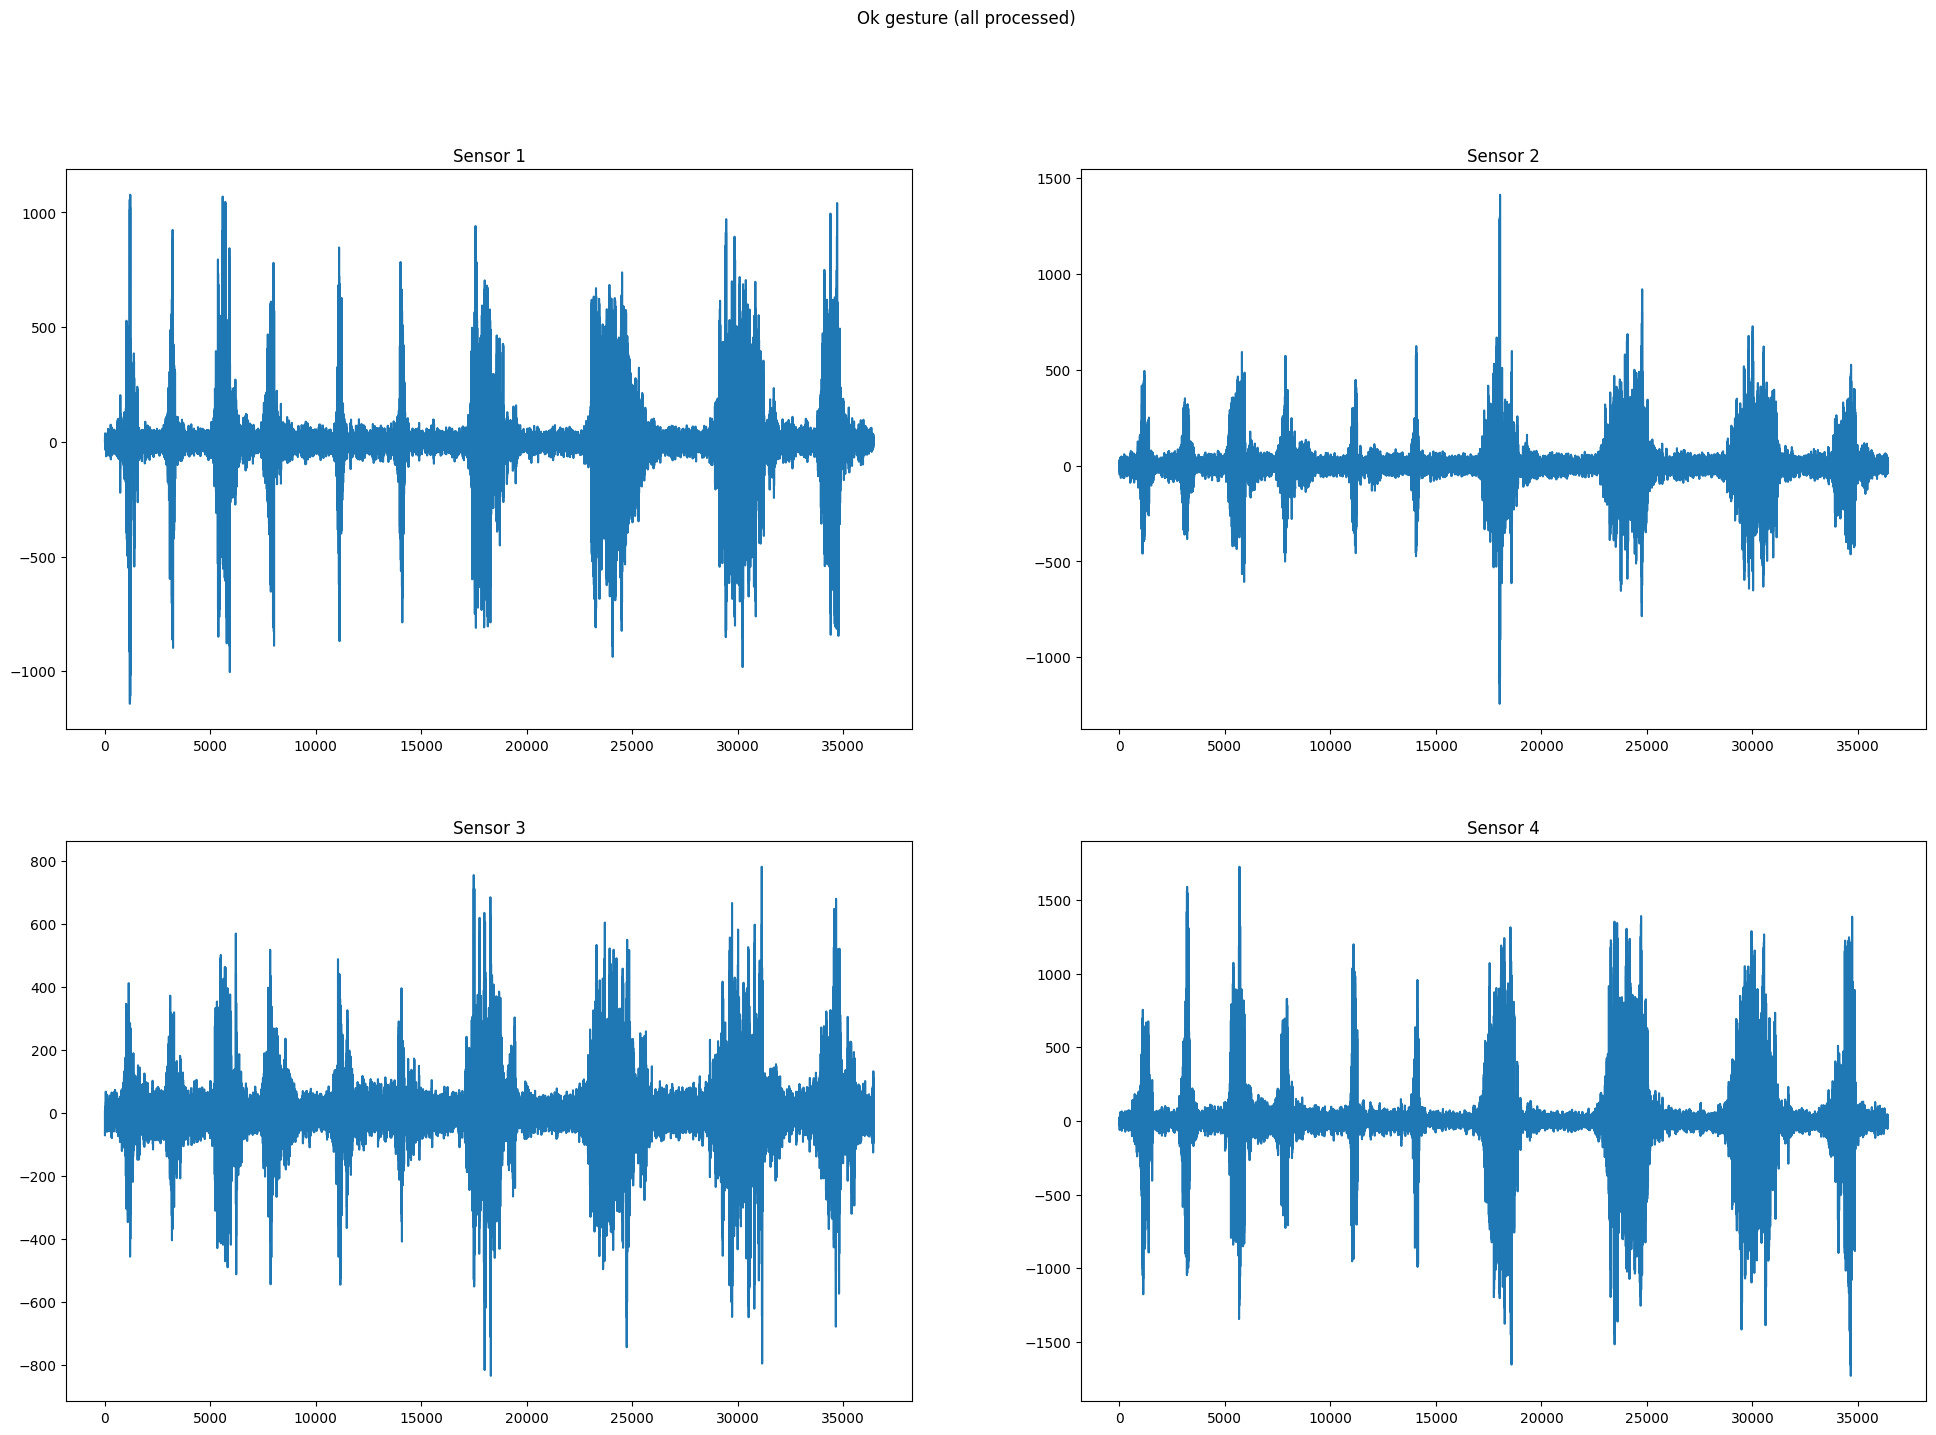

In [27]:
def plot_signal(data, row_index, title):
    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(data, NUM_SENSORS, axis=1)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_signals(preprocessor, all_data, title, filter=False): 
    # Plot each sensor's signal
    signals = np.array_split(all_data, NUM_SENSORS, axis=1)
    fig, axs = plt.subplots(NUM_SENSORS // 2 + NUM_SENSORS % 2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        # mean = np.mean(sigs, axis=0)
        # std = np.std(sigs, axis=0)
        # sigs = (sigs - mean) #/ std
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))

        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

# index = 3
# raw_signal = fist_df.iloc[index, :-1].values
# plot_signal(raw_signal, row_index=index, title='Fist gesture')
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.values, filter_type='band', library='scipy')
# proc_data = preprocessor.preprocess(raw_signal)
# plot_signal(proc_data, row_index=index, title='Fist gesture (processed)')

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, baseline_array.flatten(), filter_type='highlow', library='libemg')
# raw_signal = ok_df.values
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, np.zeros(concat_dfs[0].shape), filter_type='band', library='libemg', num_sensors=NUM_SENSORS)
raw_signal = concat_dfs[0].values
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

# # preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

## Class distribution

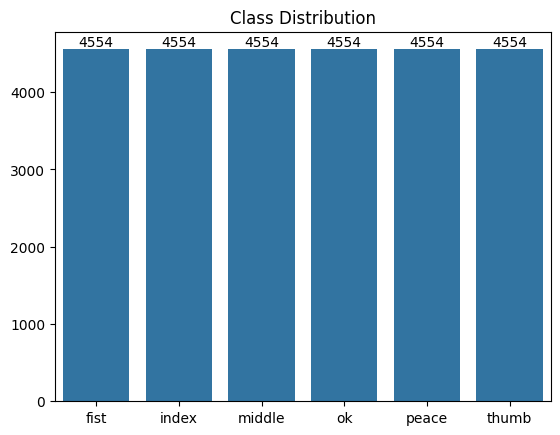

In [28]:
ax = sns.barplot(x=GESTURES, y=[len(df) for df in concat_dfs])
ax.bar_label(ax.containers[0])

plt.title('Class Distribution')
plt.show()

## Sensor correlation analysis

C:\Users\Gilbert\AppData\Local\Temp\ipykernel_20648\2709244429.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


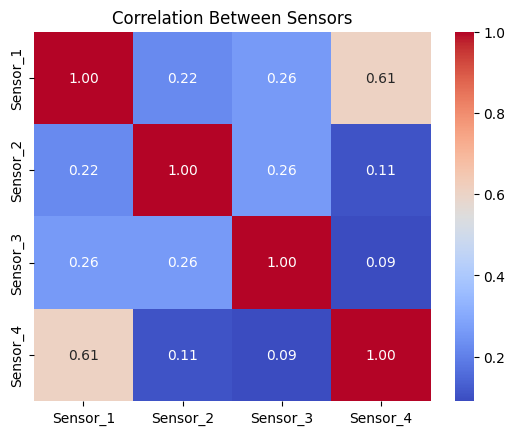

In [29]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(NUM_SENSORS)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

C:\Users\Gilbert\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


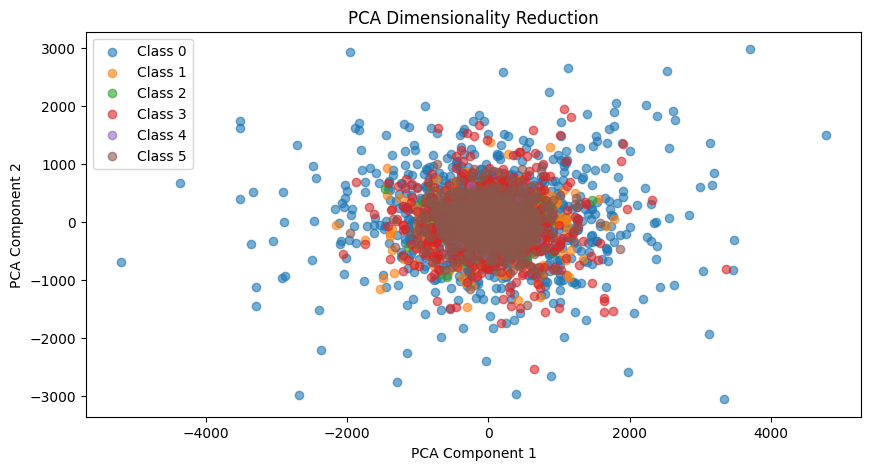

In [30]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
shape = sensor_data.shape
sensor_data_array = concat_dfs
sensor_preproc = [[] for _ in range(NUM_CLASSES)]
for i in range(NUM_CLASSES):
    shape_per_sensor = sensor_data_array[i].shape
    signals = np.array_split(sensor_data_array[i], NUM_SENSORS, axis=1)
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sig_shape = sigs.shape
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = sigs.reshape(sig_shape)
        signals[sensor] = sigs

    sensor_preproc[i] = np.asarray(signals).reshape(shape_per_sensor)
    
sensor_preproc = np.concatenate(sensor_preproc)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [31]:
# # t-SNE Dimensionality Reduction to 2 components
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(sensor_preproc)

# Plot t-SNE results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

KeyboardInterrupt: 

## Train networks

In [32]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, np.zeros(concat_dfs[0].shape), filter_type='band', library='libemg')

Baseline signal provided
Baseline noise:  0.0
Baseline noise:  0.0
Baseline noise:  0.0
Baseline noise:  0.0


In [52]:
from libemg.utils import get_windows
from libemg.feature_extractor import FeatureExtractor

def preprocess_per_sensor(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100):
    raw_signal = df.values
    signals = np.array_split(raw_signal, num_sensors, axis=1)
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = sigs.reshape(-1, 8)
        signals[sensor] = sigs
    raw_signal = np.concatenate(signals, axis=1)
    raw_signal = np.hstack([raw_signal[:, i::8] for i in range(8)])
    raw_signal = raw_signal.reshape(-1, num_sensors)
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_features_per_sensor(windows, feature_groups=('HTD',)):
    fe = FeatureExtractor()
    
    features_list = []
    
    for feature_group in feature_groups:
        if feature_group not in fe.get_feature_groups().keys():
            raise ValueError(f"Invalid feature group: {feature_group}")

        features = fe.extract_feature_group(feature_group, windows, array=True)
        features_list.append(features)
    return np.concatenate(features_list, axis=1)


In [53]:
windows = [[] for _ in range(NUM_CLASSES)]
data_arrays = [[] for _ in range(NUM_CLASSES)]
for i, df in enumerate(concat_dfs):
    data_arrays[i], windows[i] = preprocess_per_sensor(df, preprocessor, i, num_sensors=NUM_SENSORS, window_size=200)

features = [[] for _ in range(NUM_CLASSES)]
for i in range(NUM_CLASSES):
    features[i] = np.hstack((get_features_per_sensor(windows[i], feature_groups=('HJORTH', 'HTD')), np.full((windows[i].shape[0], 1), i)))

In [54]:
X = np.vstack([arr[:, :-1] for arr in data_arrays])
y = np.hstack([arr[:, -1] for arr in data_arrays])

X_feat = np.vstack([arr[:, :-1] for arr in features])
y_feat = y

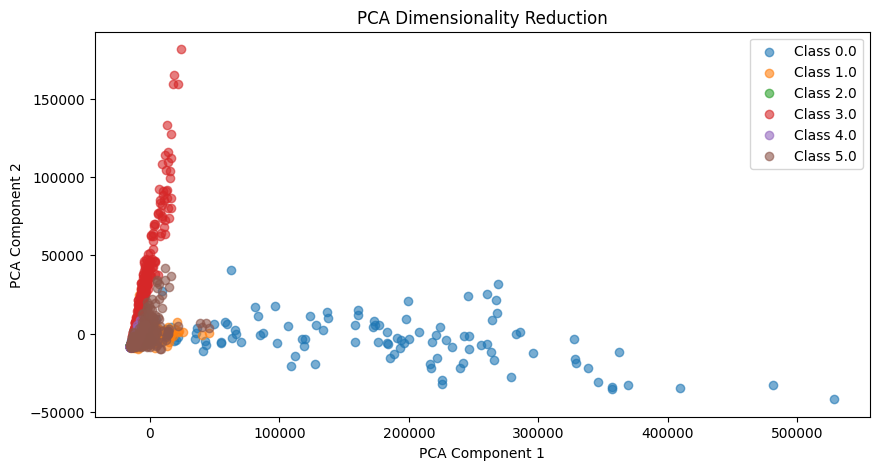

In [55]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_feat)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(y_feat):
    plt.scatter(pca_result[y_feat == class_id, 0], pca_result[y_feat == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [196]:
# # t-SNE Dimensionality Reduction to 2 components
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(X_feat)

# Plot t-SNE results
plt.figure(figsize=(10, 5))
for class_id in np.unique(y_feat):
    plt.scatter(tsne_result[y_feat == class_id, 0], tsne_result[y_feat == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

KeyboardInterrupt: 

In [56]:
print(X.shape, y.shape, X_feat.shape, y_feat.shape)

(2178, 800) (2178,) (2178, 28) (2178,)


In [57]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

1725.533299203685 -1730.7198999515208 513944.4263861342 0.41484893950115737


Use separate scalars for raw data and features and save both:

In [58]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

with open("scaler_raw_data.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [59]:
scaler = StandardScaler()

X_feat = scaler.fit_transform(X_feat)

with open("scalar_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [60]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

23.325821851921983 -20.92104289508415 17.22788120055057 -5.979876709345129


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feat, y_feat, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

In [62]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train_feat.shape, X_test_feat.shape, y_train_feat.shape, y_test_feat.shape

((1742, 28), (436, 28), (1742,), (436,))

In [63]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0., 1., 2., 3., 4., 5.]), array([75, 80, 63, 70, 73, 75], dtype=int64))

## Classical models

In [64]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=RANDOM_STATE)
# clf.fit(X_train, y_train)
clf.fit(X_train_feat, y_train_feat)

RandomForestClassifier(max_depth=100, random_state=42)

In [65]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(13, 25)

In [66]:
with open("random_forest_model.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [67]:
y_pred = clf.predict(X_train_feat)

print('Classification Report: \n', classification_report(y_train_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       288
         1.0       1.00      1.00      1.00       283
         2.0       1.00      1.00      1.00       300
         3.0       1.00      1.00      1.00       293
         4.0       1.00      1.00      1.00       290
         5.0       1.00      1.00      1.00       288

    accuracy                           1.00      1742
   macro avg       1.00      1.00      1.00      1742
weighted avg       1.00      1.00      1.00      1742

Confusion Matrix: 
 [[288   0   0   0   0   0]
 [  0 283   0   0   0   0]
 [  0   0 300   0   0   0]
 [  0   0   0 293   0   0]
 [  0   0   0   0 290   0]
 [  0   0   0   0   0 288]]


In [68]:
y_pred = clf.predict(X_test_feat)

In [69]:
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        75
         1.0       0.80      0.82      0.81        80
         2.0       0.92      0.89      0.90        63
         3.0       0.96      0.99      0.97        70
         4.0       0.97      0.96      0.97        73
         5.0       0.79      0.77      0.78        75

    accuracy                           0.90       436
   macro avg       0.91      0.91      0.91       436
weighted avg       0.90      0.90      0.90       436

Confusion Matrix: 
 [[75  0  0  0  0  0]
 [ 0 66  2  2  0 10]
 [ 0  2 56  0  2  3]
 [ 0  0  0 69  0  1]
 [ 0  0  2  0 70  1]
 [ 0 15  1  1  0 58]]


## Test different classical ML models

Testing different classification models with common parameters based on https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html.

In [70]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=RANDOM_STATE),
    SVC(gamma=2, C=1, random_state=RANDOM_STATE),
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=RANDOM_STATE
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=RANDOM_STATE),
    AdaBoostClassifier(algorithm="SAMME", random_state=RANDOM_STATE),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf.fit(X_train_feat, y_train_feat)
    y_pred = clf.predict(X_test_feat)
    
    print(f'{name} results:')
    print('Classification Report: \n', classification_report(y_test_feat, y_pred))
    print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))
    print()

Nearest Neighbors results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.95      0.92      0.93        75
         1.0       0.51      0.65      0.57        80
         2.0       0.45      0.60      0.52        63
         3.0       0.97      0.83      0.89        70
         4.0       0.69      0.67      0.68        73
         5.0       0.67      0.41      0.51        75

    accuracy                           0.68       436
   macro avg       0.71      0.68      0.68       436
weighted avg       0.71      0.68      0.69       436

Confusion Matrix: 
 [[69  4  0  2  0  0]
 [ 1 52 16  0  7  4]
 [ 0 13 38  0 10  2]
 [ 3  5  1 58  1  2]
 [ 0  8  9  0 49  7]
 [ 0 20 20  0  4 31]]

Linear SVM results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.99        75
         1.0       0.66      0.66      0.66        80
         2.0       0.65      0.75      0.70      

c:\Users\Gilbert\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gilbert\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gilbert\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

Neural Net results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99        75
         1.0       0.83      0.86      0.85        80
         2.0       0.88      0.97      0.92        63
         3.0       1.00      0.97      0.99        70
         4.0       0.99      0.93      0.96        73
         5.0       0.90      0.85      0.88        75

    accuracy                           0.93       436
   macro avg       0.93      0.93      0.93       436
weighted avg       0.93      0.93      0.93       436

Confusion Matrix: 
 [[75  0  0  0  0  0]
 [ 0 69  3  0  1  7]
 [ 0  2 61  0  0  0]
 [ 1  1  0 68  0  0]
 [ 0  0  5  0 68  0]
 [ 0 11  0  0  0 64]]

AdaBoost results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.93      0.88      0.90        75
         1.0       0.58      0.47      0.52        80
         2.0       0.70      0.33      0.45        63
    

The models used in by libemg are also based on Scikit-Learn and mostly use the [standard parameters](https://github.com/LibEMG/libemg/blob/main/libemg/emg_predictor.py#L225):

```python
model_config = {
    'LDA': (LinearDiscriminantAnalysis, {}),
    'KNN': (KNeighborsClassifier, {"n_neighbors": 5}),
    'SVM': (SVC, {"kernel": "linear", "probability": True, "random_state": 0}),
    'QDA': (QuadraticDiscriminantAnalysis, {}),
    'RF': (RandomForestClassifier, {"random_state": 0}),
    'NB': (GaussianNB, {}),
    'GB': (GradientBoostingClassifier, {"random_state": 0}),
    'MLP': (MLPClassifier, {"random_state": 0, "hidden_layer_sizes": 126})
}
```

## Deep Learning

### Feed Forward Neural Network

The FFNN will be trained on the extracted features from the EMG signals.

In [71]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, layer_sizes, dropout_rates):
        super(NeuralNet, self).__init__()
        
        assert len(layer_sizes) >= 2, "layer_sizes must include at least input and output sizes"
        assert len(dropout_rates) == len(layer_sizes) - 2, "dropout_rates must match the number of hidden layers"
        
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(dropout_rates):  # Apply dropout only to hidden layers
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rates[i]))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


In [72]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [73]:
def train_model(model, train_dataloader, test_loader, n_epochs, learning_rate, verbose=True):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        model.train()
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        test_accuracy, test_loss = calculate_accuracy(model, test_loader)

        scheduler.step(running_loss / total)
        
        if verbose:
            epoch_loss = running_loss / len(train_dataloader.dataset)
            epoch_accuracy = correct / total * 100

            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

    return model

def calculate_accuracy(model, test_dataloader, loss_fn=nn.CrossEntropyLoss()):
    running_loss = 0.0
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total * 100, running_loss / total

In [74]:
input_size = X_train_feat.shape[1]
output_size = int(y_train_feat.max() + 1)
batch_size = 256
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train_feat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_feat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [75]:
models_architectures = [
    {'layer_sizes': [input_size, 1024, 1024, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 128, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, output_size], 'dropout_rates': [0.2]},
    {'layer_sizes': [input_size, 8, output_size], 'dropout_rates': [0.2]},
]

In [76]:
models = []

for i, architecture in enumerate(models_architectures):
    model = NeuralNet(architecture['layer_sizes'], architecture['dropout_rates']).to(device)
    print(f"Training model {i+1} with {sum(p.numel() for p in model.parameters())} weights")
    model = train_model(model, train_loader, test_loader, epochs, learning_rate, verbose=False)
    print(f"Model {i+1} train accuracy: {calculate_accuracy(model, train_loader)[0]:.2f}% test accuracy: {calculate_accuracy(model, test_loader)[0]:.2f}%\n")
    models.append(model)

Training model 1 with 1085446 weights
Model 1 train accuracy: 100.00% test accuracy: 95.18%

Training model 2 with 8038 weights
Model 2 train accuracy: 98.39% test accuracy: 94.95%

Training model 3 with 2182 weights
Model 3 train accuracy: 95.24% test accuracy: 92.89%

Training model 4 with 1126 weights
Model 4 train accuracy: 92.08% test accuracy: 91.51%

Training model 5 with 286 weights
Model 5 train accuracy: 85.02% test accuracy: 83.94%



In [77]:
model_scripted = torch.jit.script(models[1])
model_scripted.save('ffnn_model.pt')

In [78]:
model_scripted = torch.jit.script(models[3])
model_scripted.save('ffnn_model_2.pt')

In [79]:
X_test_tensor[7]

tensor([-0.3752, -0.1745, -0.3660, -0.2117,  2.4756, -0.9689,  1.0812,  1.3907,
         0.0129, -0.2836, -0.2781, -0.2671, -0.5903, -0.2940, -0.3569, -0.2958,
         1.8203,  0.1745,  1.7806,  1.5186,  1.2185, -0.1405,  0.0913, -0.2135,
        -0.4451, -0.2865, -0.2787, -0.2429])

In [80]:
logits = models[0](X_test_tensor[7].unsqueeze(0).to(device))
shifted_logits = logits - logits.min(dim=1, keepdim=True).values
normalized_logits = shifted_logits / (shifted_logits.sum(dim=1, keepdim=True) + 1e-8)
print(logits)
print(normalized_logits)

tensor([[-20.7782,   0.3449,  -5.1873, -10.6780, -11.4453,   4.0413]],
       grad_fn=<AddmmBackward0>)
tensor([[0.0000, 0.2609, 0.1926, 0.1247, 0.1153, 0.3065]],
       grad_fn=<DivBackward0>)


In [81]:
gc.collect()

327

### LSTM (Long Short-Term Memory)

Unlike the FFNN that was trained on the extracted features, the LSTM will be trained on the raw EMG signals (time series).

In [82]:
class PureLSTM(nn.Module):

    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes, bidirectional=False):
        super(PureLSTM, self).__init__()

        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.linear_1 = nn.Linear(in_features=n_hidden * (2 if bidirectional else 1), out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)

        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)

    def forward(self, x):
        device = x.device
        hidden = (
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
        )

        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1), hidden)
        out = out[:, -1, :]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)

        return out

In [83]:
n_features = NUM_SENSORS
n_sequence = int(X_train.shape[1] / n_features)
epochs = 200
learning_rate = 0.005

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_mod = X_train.reshape(X_train.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test.reshape(X_test.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Data Shape ",X_train_mod.shape)
print("Test Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train Data Shape  (1742, 800) (1742,)
Test Data Shape  (436, 800) (436,)
Train Data Shape  (1742, 200, 4)
Test Data Shape  (436, 200, 4)


In [84]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=False).to(device)

In [85]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(4, 16, num_layers=2, batch_first=True)
  (linear_1): Linear(in_features=16, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 6534


In [86]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.7987, Accuracy: 15.84%, Test Accuracy: 18.58%
Epoch 2/200, Loss: 1.7869, Accuracy: 19.69%, Test Accuracy: 26.38%
Epoch 3/200, Loss: 1.7537, Accuracy: 23.71%, Test Accuracy: 30.50%
Epoch 4/200, Loss: 1.6856, Accuracy: 26.52%, Test Accuracy: 30.05%
Epoch 5/200, Loss: 1.6134, Accuracy: 30.48%, Test Accuracy: 33.94%
Epoch 6/200, Loss: 1.5748, Accuracy: 31.57%, Test Accuracy: 34.17%
Epoch 7/200, Loss: 1.5442, Accuracy: 34.21%, Test Accuracy: 36.24%
Epoch 8/200, Loss: 1.5399, Accuracy: 35.88%, Test Accuracy: 40.14%
Epoch 9/200, Loss: 1.5082, Accuracy: 36.85%, Test Accuracy: 34.63%
Epoch 10/200, Loss: 1.5068, Accuracy: 33.70%, Test Accuracy: 39.22%
Epoch 11/200, Loss: 1.4405, Accuracy: 38.75%, Test Accuracy: 40.60%
Epoch 12/200, Loss: 1.4225, Accuracy: 39.27%, Test Accuracy: 40.60%
Epoch 13/200, Loss: 1.3823, Accuracy: 41.27%, Test Accuracy: 43.58%
Epoch 14/200, Loss: 1.3720, Accuracy: 43.46%, Test Accuracy: 43.81%
Epoch 15/200, Loss: 1.4676, Accuracy: 37.49%, Test Accura

In [115]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_model.pt')

Try LSTM with bidirectional layers.

In [116]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=True).to(device)

In [117]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(4, 16, num_layers=2, batch_first=True, bidirectional=True)
  (linear_1): Linear(in_features=32, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=6, bias=True)
)
Number of weights: 14214


In [118]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.7479, Accuracy: 22.61%, Test Accuracy: 27.38%
Epoch 2/200, Loss: 1.7364, Accuracy: 26.77%, Test Accuracy: 19.93%
Epoch 3/200, Loss: 1.7212, Accuracy: 24.45%, Test Accuracy: 25.89%
Epoch 4/200, Loss: 1.6890, Accuracy: 26.54%, Test Accuracy: 26.46%
Epoch 5/200, Loss: 1.6290, Accuracy: 28.63%, Test Accuracy: 29.67%
Epoch 6/200, Loss: 1.5717, Accuracy: 30.93%, Test Accuracy: 29.90%
Epoch 7/200, Loss: 1.6015, Accuracy: 29.18%, Test Accuracy: 29.78%
Epoch 8/200, Loss: 1.5442, Accuracy: 31.73%, Test Accuracy: 32.88%
Epoch 9/200, Loss: 1.5285, Accuracy: 32.27%, Test Accuracy: 31.16%
Epoch 10/200, Loss: 1.6421, Accuracy: 28.40%, Test Accuracy: 28.87%
Epoch 11/200, Loss: 1.6127, Accuracy: 29.92%, Test Accuracy: 26.92%
Epoch 12/200, Loss: 1.6684, Accuracy: 25.94%, Test Accuracy: 22.91%
Epoch 13/200, Loss: 1.6541, Accuracy: 26.02%, Test Accuracy: 27.95%
Epoch 14/200, Loss: 1.5504, Accuracy: 30.44%, Test Accuracy: 33.56%
Epoch 15/200, Loss: 1.5538, Accuracy: 33.59%, Test Accura

In [119]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_bidrection_model.pt')

In [120]:
def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 84.42%


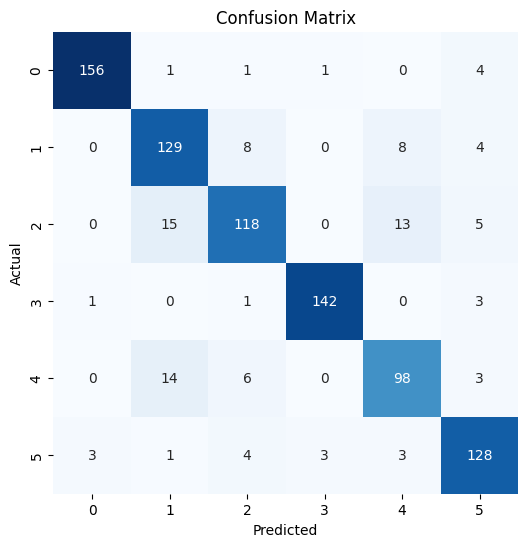

In [117]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Transformer

In [118]:
import torch
import torch.nn as nn

class TransformerTimeSeries(nn.Module):
    def __init__(self, n_features, n_sequence, n_hidden, n_heads, n_layers, n_classes, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        
        self.n_features = n_features
        self.n_sequence = n_sequence
        
        # Input embedding layer
        self.input_embedding = nn.Linear(n_features, n_hidden)
        
        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, n_sequence, n_hidden))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_hidden,
            nhead=n_heads,
            dim_feedforward=n_hidden * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Fully connected layers
        self.linear_1 = nn.Linear(n_hidden, 128)
        self.dropout_1 = nn.Dropout(p=dropout)
        self.linear_2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # Apply input embedding
        x = self.input_embedding(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Add positional encoding
        x = x + self.positional_encoding
        
        # Pass through Transformer encoder
        x = self.transformer_encoder(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Extract the representation of the last time step
        x = x[:, -1, :]  # Shape: (batch_size, n_hidden)
        
        # Pass through fully connected layers
        x = self.linear_1(x)
        x = self.dropout_1(x)
        x = self.linear_2(x)
        
        return x


In [119]:
n_heads = 4
dropout = 0.2

model = TransformerTimeSeries(n_features, n_sequence, n_hidden, n_heads, n_layers, output_size, dropout).to(device)

In [120]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.6665, Accuracy: 26.94%, Test Accuracy: 28.75%
Epoch 2/200, Loss: 1.4794, Accuracy: 34.80%, Test Accuracy: 39.40%
Epoch 3/200, Loss: 1.3228, Accuracy: 41.42%, Test Accuracy: 42.84%
Epoch 4/200, Loss: 1.2060, Accuracy: 47.49%, Test Accuracy: 53.49%
Epoch 5/200, Loss: 1.0622, Accuracy: 55.03%, Test Accuracy: 54.87%
Epoch 6/200, Loss: 0.9792, Accuracy: 60.68%, Test Accuracy: 60.60%
Epoch 7/200, Loss: 0.8942, Accuracy: 62.25%, Test Accuracy: 62.77%
Epoch 8/200, Loss: 0.8109, Accuracy: 66.24%, Test Accuracy: 64.38%
Epoch 9/200, Loss: 0.7716, Accuracy: 68.04%, Test Accuracy: 64.83%
Epoch 10/200, Loss: 0.7332, Accuracy: 70.08%, Test Accuracy: 62.43%
Epoch 11/200, Loss: 0.7270, Accuracy: 70.08%, Test Accuracy: 72.16%
Epoch 12/200, Loss: 0.7336, Accuracy: 70.39%, Test Accuracy: 68.38%
Epoch 13/200, Loss: 0.6607, Accuracy: 73.63%, Test Accuracy: 74.68%
Epoch 14/200, Loss: 0.6129, Accuracy: 75.72%, Test Accuracy: 72.62%
Epoch 15/200, Loss: 0.5987, Accuracy: 75.35%, Test Accura

In [ ]:
model_scripted = torch.jit.script(model)
model_scripted.save('transformer_model.pt')